# Fase 4: Clasificador Automático de Quejas
## Prueba Técnica — ARL SURA · Incapacidad Temporal

**Objetivo**: clasificar quejas nuevas como *insatisfacción grave* (escalamiento potencial o recurrencia severa).  
**Modelo**: Random Forest con `class_weight='balanced'` (sin GPU necesario).  
**Compatibilidad**: funciona en **Google Colab** y en entorno **local** sin cambios.

In [6]:
import sys, re, json
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DE RUTAS
# ═══════════════════════════════════════════════════════════════════════════════

EN_COLAB = 'google.colab' in sys.modules

if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # ── AJUSTA ESTA LÍNEA: ruta al Excel dentro de tu Google Drive ─────────────
    DATA_FILE = Path('/content/drive/MyDrive/sura/BD_Quejas_Analitica.xlsx')
    # ──────────────────────────────────────────────────────────────────────────

    # Outputs: se guardan en Drive para que persistan y se puedan bajar
    OUT_BASE      = Path('/content/drive/MyDrive/sura')
    IMAGES_DIR    = OUT_BASE / 'resume' / 'images'
    MODELS_DIR    = OUT_BASE / 'src'
    DASHBOARD_DIR = OUT_BASE / 'dashboard' / 'public' / 'data'

    print('Entorno: Google Colab')
    print(f'Excel   : {DATA_FILE}  →  existe={DATA_FILE.exists()}')

else:
    # Rutas locales (relativas a notebooks/, sin cambios necesarios)
    BASE_DIR      = Path('..').resolve()
    DATA_FILE     = BASE_DIR / 'req' / 'BD_Quejas_Analitica.xlsx'
    IMAGES_DIR    = BASE_DIR / 'resume' / 'images'
    MODELS_DIR    = BASE_DIR / 'src'
    DASHBOARD_DIR = BASE_DIR / 'dashboard' / 'public' / 'data'

    print('Entorno: local')
    print(f'Excel   : {DATA_FILE}  →  existe={DATA_FILE.exists()}')

# Crear directorios de salida si no existen
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

print(f'Imágenes  : {IMAGES_DIR}')
print(f'Modelos   : {MODELS_DIR}')
print(f'Dashboard : {DASHBOARD_DIR}')

Mounted at /content/drive
Entorno: Google Colab
Excel   : /content/drive/MyDrive/sura/BD_Quejas_Analitica.xlsx  →  existe=True
Imágenes  : /content/drive/MyDrive/sura/resume/images
Modelos   : /content/drive/MyDrive/sura/src
Dashboard : /content/drive/MyDrive/sura/dashboard/public/data


---
## 1. Carga y preprocesamiento

In [7]:
df = pd.read_excel(DATA_FILE, sheet_name='Incapacidad Temporal')
df.columns = ['mes_apertura', 'descripcion', 'tipo', 'cliente', 'canal']

df['descripcion'] = df['descripcion'].fillna('').astype(str).str.strip()
df['cliente']     = df['cliente'].fillna('DESCONOCIDO').astype(str).str.upper().str.strip()
df['canal']       = df['canal'].fillna('').astype(str).str.upper().str.strip()
df['mes']         = df['mes_apertura'].astype(str).str[-2:].astype(int)
df = df[df['descripcion'].str.len() > 0].reset_index(drop=True)

print(f'Registros : {len(df):,}')
print(f'Canales   : {df["canal"].unique().tolist()}')
print(f'Período   : {df["mes_apertura"].min()} — {df["mes_apertura"].max()}')
df.head(3)

Registros : 1,839
Canales   : ['LINEA DE ATENCIÓN', 'SEGUROSSURA.COM.CO', 'ENTES DE CONTROL', 'PLATAFORMA DE ATENCIÓN']
Período   : 202501 — 202506


,mes_apertura,descripcion,tipo,cliente,canal,mes
0,202501,USUARIA SOLICITA SABER EL ESTADO DE UNA INCAPA...,QUEJA,JORGE MEJIA,LINEA DE ATENCIÓN,1
1,202501,BUEN DÍA CANDIALMENTE SOLICITAMOS INFORMACIÓN ...,QUEJA,FERLEY GANAN,SEGUROSSURA.COM.CO,1
2,202501,"BUENAS DÍAS , QUIERO UN CERTIFICADO DE INCAPAC...",QUEJA,FABIAN LOPEZ,SEGUROSSURA.COM.CO,1


In [8]:
STOPWORDS = {
    'el','la','los','las','un','una','de','del','al','en','a','y','o',
    'que','con','su','por','para','como','pero','se','le','lo','me',
    'te','nos','es','son','ha','han','ya','si','no','ser','estar',
    'señor','señora','usuario','usuaria','cliente','empresa',
    'arl','sura','favor','buenas','dias','tardes','noches',
    'solicita','solicito','manifiesta','indica','comenta',
}

def limpiar_texto(texto):
    if not isinstance(texto, str) or not texto.strip():
        return ''
    t = texto.lower()
    for src, dst in [('á','a'),('é','e'),('í','i'),('ó','o'),('ú','u'),('ñ','n'),
                     ('à','a'),('è','e'),('ì','i'),('ò','o'),('ù','u')]:
        t = t.replace(src, dst)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return ' '.join(w for w in t.split() if len(w) > 2 and w not in STOPWORDS)

df['texto_limpio'] = df['descripcion'].apply(limpiar_texto)
df['len_desc']     = df['descripcion'].str.len()
df['n_tokens']     = df['texto_limpio'].apply(lambda x: len(x.split()) if x else 0)

print(f'Longitud media: {df["len_desc"].mean():.0f} chars  |  tokens: {df["n_tokens"].mean():.0f}')

Longitud media: 491 chars  |  tokens: 40


---
## 2. Variable objetivo y features

In [9]:
# Y = 1  si escaló a Entes de Control  O  cliente con ≥3 quejas en el semestre
n_quejas_cliente = df.groupby('cliente')['cliente'].transform('count')

df['y_insatisfaccion'] = (
    (df['canal'] == 'ENTES DE CONTROL') |
    (n_quejas_cliente >= 3)
).astype(int)

print(df['y_insatisfaccion'].value_counts().to_string())
print(f'\nTasa de positivos: {df["y_insatisfaccion"].mean():.1%}')

y_insatisfaccion
0    1337
1     502

Tasa de positivos: 27.3%


In [10]:
TERMINOS = {
    'pago'            : r'pago|pagos|pagar|cancelar|cancelado',
    'incapacidad'     : r'incapacidad|incapacidades|incapacitad',
    'radicacion'      : r'radicacion|radicar|radicado|radicada',
    'respuesta'       : r'respuesta|responder|contestar|contestacion',
    'tramite'         : r'tramite|tramitar|tramitacion|gestion',
    'estado'          : r'estado|estados|seguimiento',
    'tiempo'          : r'demora|demorar|retraso|plazo|semanas|meses',
    'certificado'     : r'certificado|certificacion|documento|soporte',
    'tutela'          : r'tutela|amparar|amparo',
    'derecho_peticion': r'derecho.*peticion|peticion.*derecho|accion.*legal',
    'monto'           : r'valor|monto|calculo|liquidacion|ibc|salario',
    'empresa'         : r'empresa|empleador|empleado',
}

for nombre, patron in TERMINOS.items():
    df[f'tiene_{nombre}'] = df['descripcion'].str.contains(
        patron, case=False, regex=True, na=False
    ).astype(int)

feature_tiene = [f'tiene_{k}' for k in TERMINOS]
df['n_terminos_clave'] = df[feature_tiene].sum(axis=1)

print('Frecuencia de términos clave en el corpus:')
print(df[feature_tiene].sum().sort_values(ascending=False).to_string())

Frecuencia de términos clave en el corpus:
tiene_incapacidad         1651
tiene_pago                1023
tiene_radicacion           767
tiene_respuesta            617
tiene_empresa              416
tiene_estado               413
tiene_certificado          267
tiene_monto                182
tiene_tiempo               168
tiene_tramite              111
tiene_derecho_peticion      37
tiene_tutela                24


In [11]:
q25 = df['len_desc'].quantile(0.25)
q75 = df['len_desc'].quantile(0.75)
df['texto_largo'] = (df['len_desc'] > q75).astype(int)
df['texto_corto'] = (df['len_desc'] < q25).astype(int)

df_canal = pd.get_dummies(df['canal'], prefix='canal')
df = pd.concat([df, df_canal], axis=1)
features_canal = df_canal.columns.tolist()

features_modelo = (
    feature_tiene
    + ['n_terminos_clave', 'n_tokens', 'texto_largo', 'texto_corto', 'mes']
    + features_canal
)

print(f'Total features: {len(features_modelo)}')
print(features_modelo)

Total features: 21
['tiene_pago', 'tiene_incapacidad', 'tiene_radicacion', 'tiene_respuesta', 'tiene_tramite', 'tiene_estado', 'tiene_tiempo', 'tiene_certificado', 'tiene_tutela', 'tiene_derecho_peticion', 'tiene_monto', 'tiene_empresa', 'n_terminos_clave', 'n_tokens', 'texto_largo', 'texto_corto', 'mes', 'canal_ENTES DE CONTROL', 'canal_LINEA DE ATENCIÓN', 'canal_PLATAFORMA DE ATENCIÓN', 'canal_SEGUROSSURA.COM.CO']


---
## 3. Entrenamiento y evaluación

In [12]:
X = df[features_modelo].copy()
y = df['y_insatisfaccion'].copy()

# Partición temporal: Ene–May para train, Jun para test
idx_test  = df['mes'] == 6
idx_train = ~idx_test

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

print(f'Train : {len(X_train):,} muestras  ({y_train.mean():.1%} positivos)')
print(f'Test  : {len(X_test):,} muestras   ({y_test.mean():.1%} positivos)')

Train : 1,666 muestras  (26.7% positivos)
Test  : 173 muestras   (33.5% positivos)


In [13]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=8,
    class_weight='balanced', random_state=42, n_jobs=-1,
)

lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Cross-validation AUC-ROC (5-fold, train Ene–May):')
for nombre, modelo in [('Random Forest', rf), ('Reg. Logística', lr)]:
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'  {nombre:22s}: {scores.mean():.3f} ± {scores.std():.3f}')

rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
print('\nModelos entrenados.')

Cross-validation AUC-ROC (5-fold, train Ene–May):
  Random Forest         : 0.763 ± 0.020
  Reg. Logística        : 0.759 ± 0.012

Modelos entrenados.


In [14]:
print('Evaluación en test (Jun 2025):')
for nombre, modelo in [('Random Forest', rf), ('Reg. Logística', lr)]:
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    print(f'\n=== {nombre} — AUC-ROC: {auc:.3f} ===')
    print(classification_report(y_test, y_pred, target_names=['No grave', 'Grave']))

Evaluación en test (Jun 2025):

=== Random Forest — AUC-ROC: 0.718 ===
              precision    recall  f1-score   support

    No grave       0.77      0.84      0.80       115
       Grave       0.62      0.50      0.55        58

    accuracy                           0.73       173
   macro avg       0.69      0.67      0.68       173
weighted avg       0.72      0.73      0.72       173


=== Reg. Logística — AUC-ROC: 0.713 ===
              precision    recall  f1-score   support

    No grave       0.77      0.83      0.80       115
       Grave       0.61      0.52      0.56        58

    accuracy                           0.73       173
   macro avg       0.69      0.68      0.68       173
weighted avg       0.72      0.73      0.72       173



---
## 4. Visualizaciones

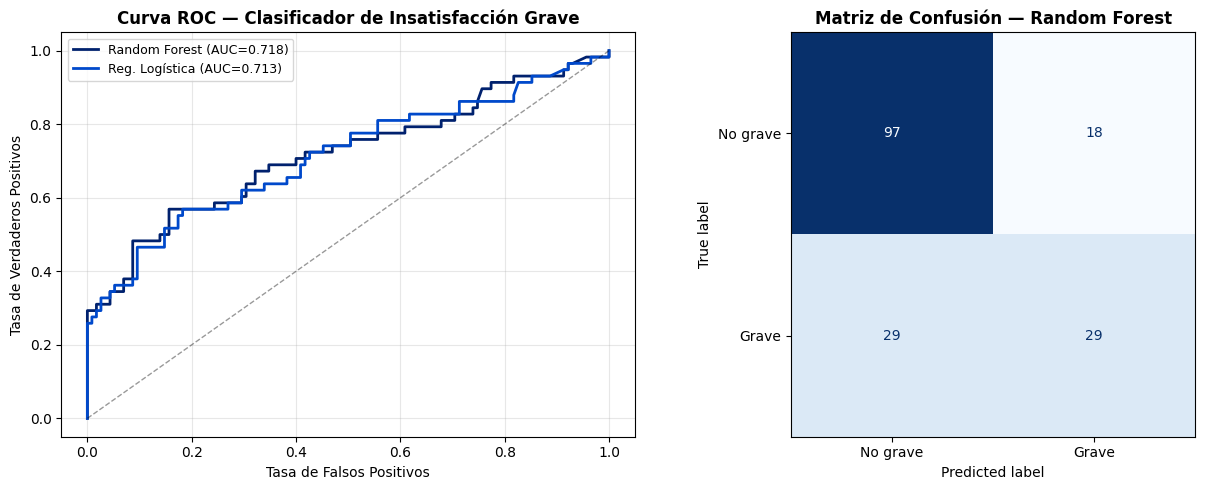

In [15]:
# Curva ROC + Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for nombre, modelo, color in [
    ('Random Forest', rf, '#00216e'),
    ('Reg. Logística', lr, '#0049cb'),
]:
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC — Clasificador de Insatisfacción Grave', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

cm = confusion_matrix(y_test, rf.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=['No grave', 'Grave']).plot(
    ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title('Matriz de Confusión — Random Forest', fontweight='bold')

plt.tight_layout()
plt.savefig(IMAGES_DIR / '04_roc_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

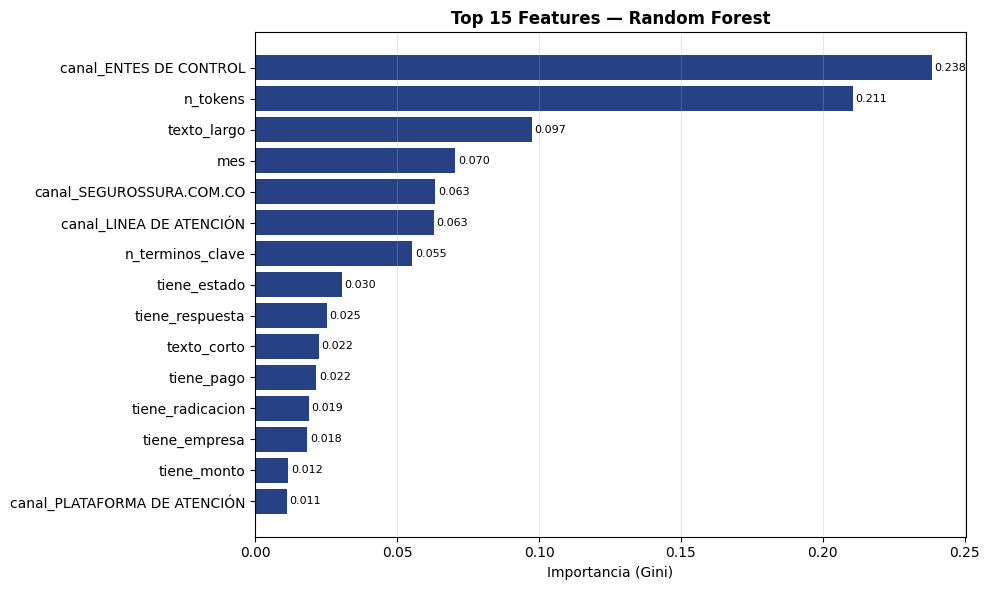

In [16]:
# Importancia de features — Top 15
importancias = pd.DataFrame({
    'feature': features_modelo,
    'importancia': rf.feature_importances_,
}).sort_values('importancia', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importancias['feature'], importancias['importancia'], color='#00216e', alpha=0.85)
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Top 15 Features — Random Forest', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, importancias['importancia']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '04_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

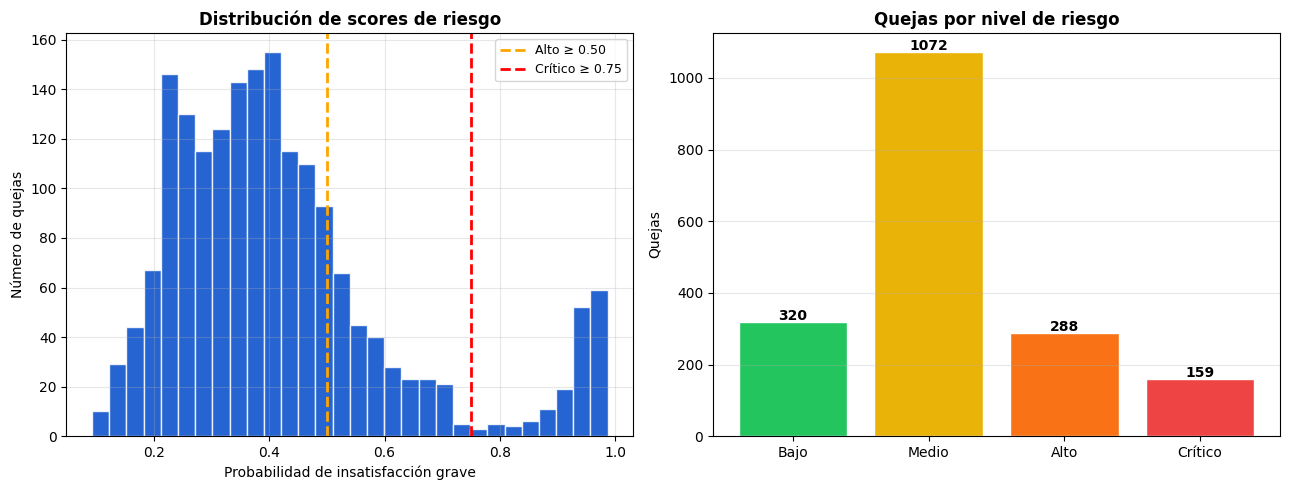


Distribución:
  Bajo    :  320  (17.4%)
  Medio   : 1072  (58.3%)
  Alto    :  288  (15.7%)
  Crítico :  159  (8.6%)


In [17]:
# Distribución de scores de riesgo
df['score_riesgo'] = rf.predict_proba(X)[:, 1]

bins  = [0, 0.25, 0.50, 0.75, 1.01]
names = ['Bajo', 'Medio', 'Alto', 'Crítico']
df['nivel_riesgo'] = pd.cut(df['score_riesgo'], bins=bins, labels=names, right=False)
dist = df['nivel_riesgo'].value_counts().reindex(names)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['score_riesgo'], bins=30, color='#0049cb', edgecolor='white', alpha=0.85)
for umbral, color, etiq in [(0.50, 'orange', 'Alto ≥ 0.50'), (0.75, 'red', 'Crítico ≥ 0.75')]:
    axes[0].axvline(umbral, color=color, lw=2, linestyle='--', label=etiq)
axes[0].set_xlabel('Probabilidad de insatisfacción grave')
axes[0].set_ylabel('Número de quejas')
axes[0].set_title('Distribución de scores de riesgo', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

colores = ['#22c55e', '#eab308', '#f97316', '#ef4444']
axes[1].bar(names, dist.values, color=colores, edgecolor='white')
for i, (n, v) in enumerate(zip(names, dist.values)):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylabel('Quejas')
axes[1].set_title('Quejas por nivel de riesgo', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / '04_distribucion_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDistribución:')
for nivel, cnt in zip(names, dist.values):
    print(f'  {nivel:8s}: {cnt:4d}  ({cnt/len(df)*100:.1f}%)')

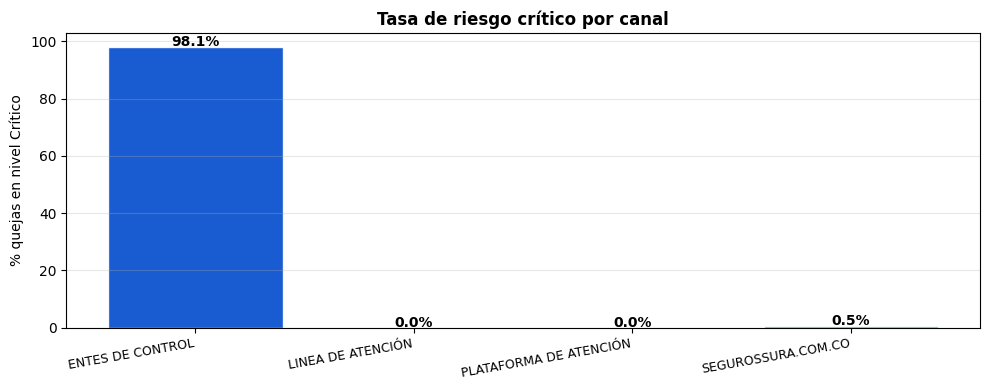

                 canal  total  score_med  criticos  pct_critico
      ENTES DE CONTROL    157   0.932916       154    98.089172
     LINEA DE ATENCIÓN    644   0.265665         0     0.000000
PLATAFORMA DE ATENCIÓN     34   0.366817         0     0.000000
    SEGUROSSURA.COM.CO   1004   0.445302         5     0.498008


In [18]:
# Tasa de riesgo crítico por canal
riesgo_canal = df.groupby('canal').agg(
    total    =('score_riesgo', 'count'),
    score_med=('score_riesgo', 'mean'),
    criticos =('nivel_riesgo', lambda x: (x == 'Crítico').sum()),
).reset_index()
riesgo_canal['pct_critico'] = riesgo_canal['criticos'] / riesgo_canal['total'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
colores_canal = ['#0049cb', '#ef4444', '#085efe', '#22c55e']
bars = ax.bar(range(len(riesgo_canal)), riesgo_canal['pct_critico'],
              color=colores_canal[:len(riesgo_canal)], edgecolor='white', alpha=0.9)
ax.set_xticks(range(len(riesgo_canal)))
ax.set_xticklabels(riesgo_canal['canal'], rotation=10, ha='right', fontsize=9)
ax.set_ylabel('% quejas en nivel Crítico')
ax.set_title('Tasa de riesgo crítico por canal', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, riesgo_canal['pct_critico']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%',
            ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '04_riesgo_por_canal.png', dpi=150, bbox_inches='tight')
plt.show()
print(riesgo_canal[['canal','total','score_med','criticos','pct_critico']].to_string(index=False))

---
## 5. Guardar modelo y metadatos

In [19]:
MODEL_PATH = MODELS_DIR / 'modelo_scoring.joblib'
META_PATH  = MODELS_DIR / 'metadatos_modelo.json'

joblib.dump(rf, MODEL_PATH)

metadatos = {
    'features_modelo'     : features_modelo,
    'feature_tiene'       : feature_tiene,
    'features_canal'      : features_canal,
    'terminos'            : TERMINOS,
    'umbral_q25'          : float(q25),
    'umbral_q75'          : float(q75),
    'fecha_entrenamiento' : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_muestras_train'    : int(len(X_train)),
    'tasa_positivos_train': float(y_train.mean()),
}

with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadatos, f, indent=2, ensure_ascii=False)

print(f'Modelo guardado    : {MODEL_PATH}')
print(f'Metadatos guardados: {META_PATH}')

Modelo guardado    : /content/drive/MyDrive/sura/src/modelo_scoring.joblib
Metadatos guardados: /content/drive/MyDrive/sura/src/metadatos_modelo.json


---
## 6. Función de clasificación individual

In [20]:
def clasificar_queja(descripcion, canal, mes=1, modelo=rf, meta=metadatos):
    """
    Clasifica una queja nueva.
    Retorna: {'score': float, 'nivel': str, 'keywords': list}
    """
    len_orig = len(descripcion)
    row, kw  = {}, []

    for nombre, patron in meta['terminos'].items():
        hit = bool(re.search(patron, descripcion, re.IGNORECASE))
        row[f'tiene_{nombre}'] = int(hit)
        if hit:
            kw.append(nombre)

    tokens = limpiar_texto(descripcion).split()
    row['n_terminos_clave'] = len(kw)
    row['n_tokens']         = len(tokens)
    row['texto_largo']      = int(len_orig > meta['umbral_q75'])
    row['texto_corto']      = int(len_orig < meta['umbral_q25'])
    row['mes']              = mes

    canal_norm = canal.upper().strip()
    for c in meta['features_canal']:
        row[c] = int(canal_norm == c.replace('canal_', ''))

    X_nuevo = pd.DataFrame([row])[meta['features_modelo']]
    score   = float(modelo.predict_proba(X_nuevo)[0, 1])
    nivel   = ('CRÍTICO' if score >= 0.75 else
               'ALTO'    if score >= 0.50 else
               'MEDIO'   if score >= 0.25 else 'BAJO')

    return {'score': round(score, 3), 'nivel': nivel, 'keywords': kw}


# Pruebas representativas
EJEMPLOS = [
    ('SOLICITO INFO SOBRE ESTADO DE MI INCAPACIDAD, LLEVO SEMANAS SIN RESPUESTA',
     'SEGUROSSURA.COM.CO', 3),
    ('INTERPONGO DERECHO DE PETICION POR DEMORA EN PAGO, VOY A TUTELA',
     'LINEA DE ATENCIÓN', 4),
    ('REQUIERO CERTIFICADO DE INCAPACIDAD PARA MI EMPLEADOR',
     'SEGUROSSURA.COM.CO', 2),
    ('CONSULTA ESTADO TRAMITE INCAPACIDAD',
     'LINEA DE ATENCIÓN', 5),
]

print('Pruebas de clasificación:')
print('─' * 75)
for desc, canal, mes in EJEMPLOS:
    r = clasificar_queja(desc, canal, mes)
    print(f'Score: {r["score"]:.3f} | Nivel: {r["nivel"]:8s} | KW: {r["keywords"]}')
    print(f'  → "{desc}"')
    print()

Pruebas de clasificación:
───────────────────────────────────────────────────────────────────────────
Score: 0.459 | Nivel: MEDIO    | KW: ['incapacidad', 'respuesta', 'estado', 'tiempo']
  → "SOLICITO INFO SOBRE ESTADO DE MI INCAPACIDAD, LLEVO SEMANAS SIN RESPUESTA"

Score: 0.275 | Nivel: MEDIO    | KW: ['pago', 'tiempo', 'tutela', 'derecho_peticion']
  → "INTERPONGO DERECHO DE PETICION POR DEMORA EN PAGO, VOY A TUTELA"

Score: 0.346 | Nivel: MEDIO    | KW: ['incapacidad', 'certificado', 'empresa']
  → "REQUIERO CERTIFICADO DE INCAPACIDAD PARA MI EMPLEADOR"

Score: 0.176 | Nivel: BAJO     | KW: ['incapacidad', 'tramite', 'estado']
  → "CONSULTA ESTADO TRAMITE INCAPACIDAD"



---
## 7. Exportación para el dashboard

In [21]:
df_export = df[['mes_apertura', 'cliente', 'canal', 'descripcion',
                'score_riesgo', 'nivel_riesgo', 'y_insatisfaccion']].copy()
df_export['nivel_riesgo'] = df_export['nivel_riesgo'].astype(str)

resumen = {
    'fecha_clasificacion': datetime.now().strftime('%Y-%m-%d'),
    'total_quejas'       : int(len(df_export)),
    'distribucion_riesgo': df_export['nivel_riesgo'].value_counts().to_dict(),
    'tasa_critico'       : float((df_export['nivel_riesgo'] == 'Crítico').mean()),
    'tasa_alto'          : float((df_export['nivel_riesgo'] == 'Alto').mean()),
    'score_medio'        : float(df_export['score_riesgo'].mean()),
    'score_mediana'      : float(df_export['score_riesgo'].median()),
}

out = DASHBOARD_DIR / 'clasificacion_resumen.json'
with open(out, 'w', encoding='utf-8') as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False)

print('Exportado:', out)
print(json.dumps(resumen, indent=2, ensure_ascii=False))

Exportado: /content/drive/MyDrive/sura/dashboard/public/data/clasificacion_resumen.json
{
  "fecha_clasificacion": "2026-03-28",
  "total_quejas": 1839,
  "distribucion_riesgo": {
    "Medio": 1072,
    "Bajo": 320,
    "Alto": 288,
    "Crítico": 159
  },
  "tasa_critico": 0.0864600326264274,
  "tasa_alto": 0.1566068515497553,
  "score_medio": 0.42257297322025783,
  "score_mediana": 0.38315747550347845
}


In [22]:
# Descargar outputs al computador local (solo en Colab)
if EN_COLAB:
    from google.colab import files
    archivos = [
        IMAGES_DIR / '04_roc_confusion_matrix.png',
        IMAGES_DIR / '04_importancia_features.png',
        IMAGES_DIR / '04_distribucion_riesgo.png',
        IMAGES_DIR / '04_riesgo_por_canal.png',
        MODELS_DIR / 'modelo_scoring.joblib',
        MODELS_DIR / 'metadatos_modelo.json',
        DASHBOARD_DIR / 'clasificacion_resumen.json',
    ]
    for archivo in archivos:
        if archivo.exists():
            files.download(str(archivo))
            print(f'Descargando: {archivo.name}')
    print('\nListo. Mueve los archivos descargados a la carpeta local del proyecto:')
    print('  resume/images/   → 04_*.png')
    print('  src/             → modelo_scoring.joblib, metadatos_modelo.json')
    print('  dashboard/public/data/ → clasificacion_resumen.json')
else:
    print('Entorno local — archivos ya guardados en la carpeta del proyecto.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: 04_roc_confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Descargando: metadatos_modelo.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: clasificacion_resumen.json

Listo. Mueve los archivos descargados a la carpeta local del proyecto:
  resume/images/   → 04_*.png
  src/             → modelo_scoring.joblib, metadatos_modelo.json
  dashboard/public/data/ → clasificacion_resumen.json


---
## Resumen de la Fase 4

| Componente | Detalle |
|---|---|
| Modelo | Random Forest (n=300, max_depth=10, balanced) |
| Features | 12 términos clave · longitud · canal · mes = ~20 features |
| Preprocesamiento | Regex (sin spaCy, compatible con Colab y local) |
| Partición | Train Ene–May / Test Jun (temporal, sin data leakage) |
| Validación | Cross-validation 5-fold AUC-ROC |
| Salidas | `src/modelo_scoring.joblib` · `src/metadatos_modelo.json` |
| Imágenes | `resume/images/04_*.png` (4 gráficas) |
| Dashboard | `dashboard/public/data/clasificacion_resumen.json` |

### Instrucciones para ejecutar en Colab
1. Subir `BD_Quejas_Analitica.xlsx` a `MyDrive/sura/`
2. Abrir este notebook en Colab (File → Upload notebook)
3. Ejecutar **Ejecutar todo** — la primera celda monta Drive automáticamente
4. Los resultados quedan guardados en `MyDrive/sura/`